# Forecasting multiple independent time series

[Forecasting for machine learning](https://www.trainindata.com/p/forecasting-with-machine-learning)

In this notebook we will show how to forecast multiple **independent** time series using a **local** and **global** forecasting approach with **traditional machine learning models**. We will use the `skforecast` package to help us do this.

This notebook is adapted from the [skforecast example notebook](https://cienciadedatos.net/documentos/py44-multi-series-forecasting-skforecast.html).


## Data set synopsis

Data has been obtained from [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/data), specifically `train.csv`. This dataset contains 913,000 sales transactions from 2013–01–01 to 2017–12–31 for 50 products (SKU) in 10 stores. The goal is to predict the next 7 days sales for 50 different items in one store using the available 5 years history.

## Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Data

In [4]:
from skforecast.datasets import fetch_dataset

# Load the data
data = fetch_dataset(name="store_sales", raw=True)
data.head()

store_sales
-----------
This dataset contains 913,000 sales transactions from 2013-01-01 to 2017-12-31
for 50 products (SKU) in 10 stores.
The original data was obtained from: inversion. (2018). Store Item Demand
Forecasting Challenge. Kaggle. https://kaggle.com/competitions/demand-
forecasting-kernels-only
Shape of the dataset: (913000, 4)


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


`ForecasterAutoregMultiSeries` and `ForecasterAutoregMultiSeriesCustom` requires that each time series is a column in the dataframe and that the index is time-like (datetime or timestamp). 

So now we process the data to get dataframes in the required format.

In [5]:
# Data preprocessing

selected_store = 2
selected_items = data["item"].unique()  # All items
# selected_items = [1, 2, 3, 4, 5] # Selection of items to reduce computation time

# Filter data to specific stores and products
mask = (data["store"] == selected_store) & (data["item"].isin(selected_items))
data = data[mask].copy()

# Convert `date` column to datetime
data["date"] = pd.to_datetime(data["date"], format="%Y-%m-%d")

data.head()

,date,store,item,sales
1826,2013-01-01,2,1,12
1827,2013-01-02,2,1,16
1828,2013-01-03,2,1,16
1829,2013-01-04,2,1,20
1830,2013-01-05,2,1,16


In [6]:
# Convert to one column per time series
data = pd.pivot_table(data=data, values="sales", index="date", columns="item")

data.head()

item,1,2,3,4,5,6,7,8,9,10,...,41,42,43,44,45,46,47,48,49,50
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,12.0,41.0,19.0,21.0,4.0,34.0,39.0,49.0,28.0,51.0,...,11.0,25.0,36.0,12.0,45.0,43.0,12.0,45.0,29.0,43.0
2013-01-02,16.0,33.0,32.0,14.0,6.0,40.0,47.0,42.0,21.0,56.0,...,19.0,21.0,35.0,25.0,50.0,52.0,13.0,37.0,25.0,57.0
2013-01-03,16.0,46.0,26.0,12.0,12.0,41.0,43.0,46.0,29.0,46.0,...,23.0,20.0,52.0,18.0,56.0,30.0,5.0,45.0,30.0,45.0
2013-01-04,20.0,50.0,34.0,17.0,16.0,41.0,44.0,55.0,32.0,56.0,...,15.0,28.0,50.0,24.0,57.0,46.0,19.0,32.0,20.0,45.0
2013-01-05,16.0,44.0,25.0,14.0,9.0,47.0,55.0,64.0,45.0,53.0,...,19.0,39.0,41.0,19.0,78.0,41.0,18.0,53.0,20.0,55.0


In [7]:
# Reset column names
data.columns.name = None
data.columns = [f"item_{col}" for col in data.columns]

# Explicitly set the frequency of the data to daily.
# This would introduce missing values for missing days.
data = data.asfreq("1D")

# Sort by time
data = data.sort_index()

data.head()

,item_1,item_2,item_3,item_4,item_5,item_6,item_7,item_8,item_9,item_10,...,item_41,item_42,item_43,item_44,item_45,item_46,item_47,item_48,item_49,item_50
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,12.0,41.0,19.0,21.0,4.0,34.0,39.0,49.0,28.0,51.0,...,11.0,25.0,36.0,12.0,45.0,43.0,12.0,45.0,29.0,43.0
2013-01-02,16.0,33.0,32.0,14.0,6.0,40.0,47.0,42.0,21.0,56.0,...,19.0,21.0,35.0,25.0,50.0,52.0,13.0,37.0,25.0,57.0
2013-01-03,16.0,46.0,26.0,12.0,12.0,41.0,43.0,46.0,29.0,46.0,...,23.0,20.0,52.0,18.0,56.0,30.0,5.0,45.0,30.0,45.0
2013-01-04,20.0,50.0,34.0,17.0,16.0,41.0,44.0,55.0,32.0,56.0,...,15.0,28.0,50.0,24.0,57.0,46.0,19.0,32.0,20.0,45.0
2013-01-05,16.0,44.0,25.0,14.0,9.0,47.0,55.0,64.0,45.0,53.0,...,19.0,39.0,41.0,19.0,78.0,41.0,18.0,53.0,20.0,55.0


In [8]:
# Check if any missing values introduced
data.isnull().sum().any()

np.False_

Four of the series are plotted to understand their trends and patterns. The reader is strongly encouraged to plot several more to gain an in-depth understanding of the series.



C:\Users\nuosv\AppData\Local\Temp\ipykernel_19088\1227022470.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data.iloc[:, :4].plot(


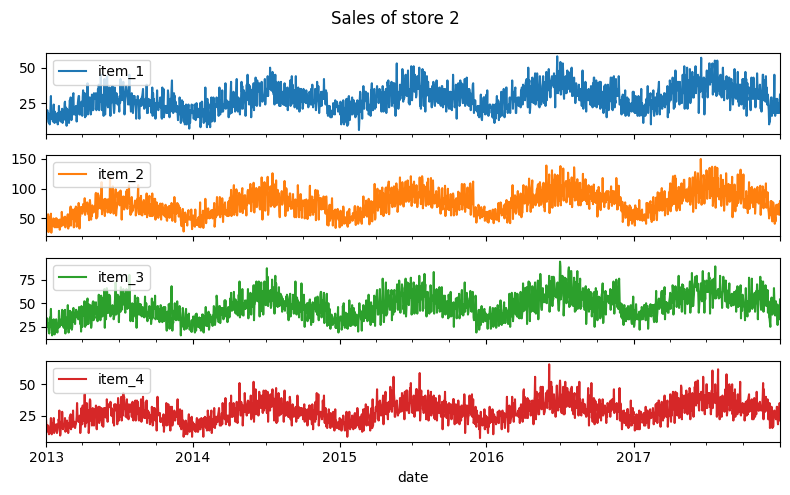

In [9]:
# Plot a subset of the time series
fig, ax = plt.subplots(figsize=(8, 5))
data.iloc[:, :4].plot(
    legend=True,
    subplots=True,
    sharex=True,
    title="Sales of store 2",
    ax=ax,
)
fig.tight_layout()

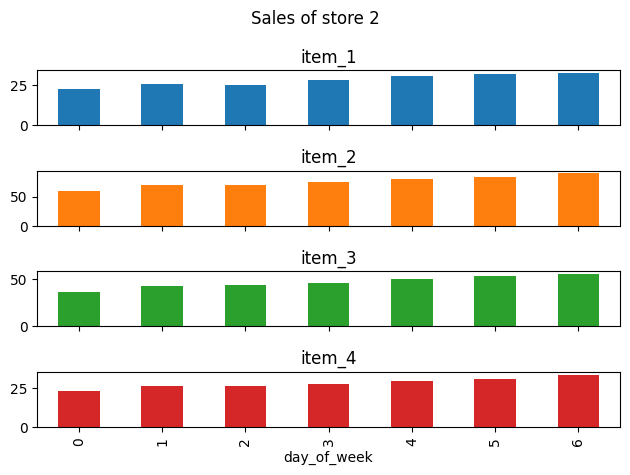

In [10]:
# Quick and dirty plot to check for weekly seasonality
(
    data.assign(day_of_week=lambda x: data.index.weekday).groupby("day_of_week").mean()
).iloc[:, :4].plot(
    legend=False,
    subplots=True,
    sharex=True,
    title="Sales of store 2",
    kind="bar",
)
plt.tight_layout()

Let's add the day of the week to use as an exogenous feature.

In [11]:
data["day_of_week"] = data.index.weekday

# Linear models would better capture seasonality using fourier or cyclical features.
# Read more about them here:
# https://www.sktime.net/en/stable/api_reference/auto_generated/sktime.transformations.series.fourier.FourierFeatures.html
# https://feature-engine.trainindata.com/en/latest/user_guide/creation/CyclicalFeatures.html#cyclical-features

In [12]:
data

,item_1,item_2,item_3,item_4,item_5,item_6,item_7,item_8,item_9,item_10,...,item_42,item_43,item_44,item_45,item_46,item_47,item_48,item_49,item_50,day_of_week
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,12.0,41.0,19.0,21.0,4.0,34.0,39.0,49.0,28.0,51.0,...,25.0,36.0,12.0,45.0,43.0,12.0,45.0,29.0,43.0,1
2013-01-02,16.0,33.0,32.0,14.0,6.0,40.0,47.0,42.0,21.0,56.0,...,21.0,35.0,25.0,50.0,52.0,13.0,37.0,25.0,57.0,2
2013-01-03,16.0,46.0,26.0,12.0,12.0,41.0,43.0,46.0,29.0,46.0,...,20.0,52.0,18.0,56.0,30.0,5.0,45.0,30.0,45.0,3
2013-01-04,20.0,50.0,34.0,17.0,16.0,41.0,44.0,55.0,32.0,56.0,...,28.0,50.0,24.0,57.0,46.0,19.0,32.0,20.0,45.0,4
2013-01-05,16.0,44.0,25.0,14.0,9.0,47.0,55.0,64.0,45.0,53.0,...,39.0,41.0,19.0,78.0,41.0,18.0,53.0,20.0,55.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-27,19.0,74.0,36.0,26.0,20.0,56.0,65.0,79.0,51.0,63.0,...,33.0,45.0,31.0,99.0,59.0,22.0,48.0,30.0,79.0,2
2017-12-28,21.0,69.0,40.0,23.0,18.0,63.0,73.0,91.0,60.0,78.0,...,46.0,64.0,31.0,99.0,64.0,24.0,37.0,31.0,68.0,3
2017-12-29,18.0,56.0,33.0,21.0,25.0,72.0,69.0,99.0,48.0,76.0,...,56.0,59.0,37.0,91.0,78.0,33.0,56.0,33.0,67.0,4


# Local forecasting approach: Training one model per time series

A different model is trained for each item of the store.

In [13]:
# Preprocessing and features
from sklearn.preprocessing import StandardScaler

# Traditional machine learning models
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

# Forecasters from skforecast
from skforecast.recursive import ForecasterRecursive
from skforecast.recursive import ForecasterRecursiveMultiSeries
from skforecast.preprocessing import RollingFeatures

In [14]:
rolling = RollingFeatures(
    stats = ['mean', 'std', 'mean', 'std'],
    window_sizes = [7, 7, 30, 30]
)

In [15]:
# Create forecaster
forecaster = ForecasterRecursive(
    regressor=Ridge(alpha=1),
    lags=7,
    window_features=rolling,
)

In [16]:
# Check the feature matrix and target variable
# created by the `forecaster` object.
time_series_1 = data["item_1"]
X_train, y_train = forecaster.create_train_X_y(y=time_series_1)
display(X_train.head(), y_train.head())

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,roll_mean_7,roll_std_7,roll_mean_30,roll_std_30
date,,,,,,,,,,,
2013-01-31,10.0,18.0,15.0,12.0,14.0,17.0,14.0,14.285714,2.751623,15.666667,4.349660
2013-02-01,16.0,10.0,18.0,15.0,12.0,14.0,17.0,14.571429,2.819997,15.800000,4.294343
2013-02-02,16.0,16.0,10.0,18.0,15.0,12.0,14.0,14.428571,2.699206,15.800000,4.294343
2013-02-03,23.0,16.0,16.0,10.0,18.0,15.0,12.0,15.714286,4.191829,16.033333,4.491243
2013-02-04,14.0,23.0,16.0,16.0,10.0,18.0,15.0,16.000000,3.958114,15.833333,4.441834


date
2013-01-31    16.0
2013-02-01    16.0
2013-02-02    23.0
2013-02-03    14.0
2013-02-04    18.0
Freq: D, Name: y, dtype: float64

In [17]:
# Target time series column names
target_cols = data.filter(like="item_").columns

# Exogenous feature column names
exog_cols = ["day_of_week"]

# Forecast horizon: Number of steps to predict
steps = 14

In [18]:
freq = data.index.freq.name
future_start_date = data.index.max() + pd.Timedelta(f"1{freq}")
future_dates = pd.date_range(start=future_start_date, freq=freq, periods=steps)

In [19]:
# Prepare exogenous features for the future
freq = data.index.freq.name
future_start_date = data.index.max() + pd.Timedelta(f"1{freq}")
future_dates = pd.date_range(start=future_start_date, freq=freq, periods=steps)

future_exog = pd.DataFrame(index=future_dates)
future_exog["day_of_week"] = future_exog.index.weekday

In [20]:
models = {}
predictions = {}

# Train a model and make a forecast for each time series
for item in target_cols:
    
    forecaster = ForecasterRecursive(
        regressor       = Ridge(alpha=1),
        lags            = 7,
        window_features = rolling
    )

    # Fit model
    forecaster.fit(y=data[item], exog=data[exog_cols])

    y_pred = forecaster.predict(steps=14, exog=future_exog)

    models[item] = forecaster
    predictions[item] = y_pred

    # Results
    forecast = pd.DataFrame(predictions)
    forecast


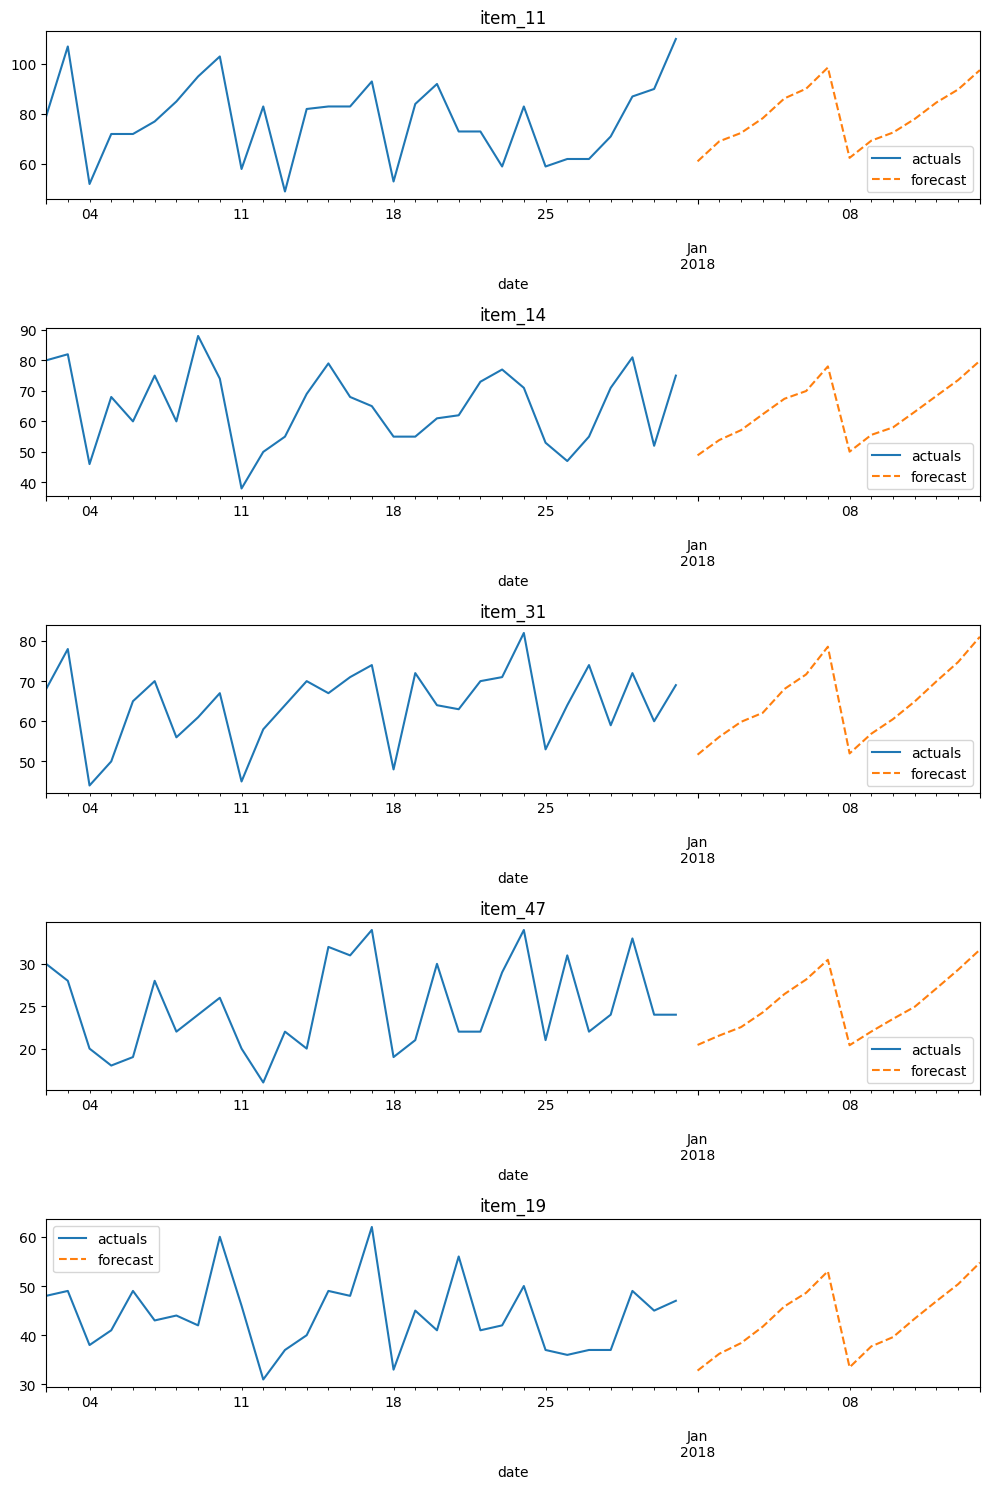

In [21]:
# Plot forecast

# Select a random subsample of timeseries
num_timeseries = 5
data_subset = data[target_cols].sample(n=num_timeseries, axis=1, random_state=123)

# Plotting
fig, axs = plt.subplots(nrows=num_timeseries, figsize=[10, 3 * num_timeseries])
for ix in range(num_timeseries):
    item = data_subset.columns[ix]
    ax = axs[ix]

    data_subset.iloc[-30:][item].plot(ax=ax, label="actuals")
    forecast.loc[:, item].plot(ax=ax, linestyle="--", label="forecast")
    ax.legend()
    ax.set_title(f"{item}")

plt.tight_layout()

In [22]:
models["item_1"].get_feature_importances()

,feature,importance
11,day_of_week,1.737551
9,roll_mean_30,0.390623
1,lag_2,0.108738
5,lag_6,0.084968
4,lag_5,0.069568
7,roll_mean_7,0.066735
0,lag_1,0.064854
2,lag_3,0.056374
3,lag_4,0.053570
8,roll_std_7,0.050095


## Global forecasting approach: Training one model for all time series

In [23]:
# Preprocessing and features
from sklearn.preprocessing import StandardScaler

# Traditional machine learning models
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

# Forecasters from skforecast (recursive)
from skforecast.ForecasterAutoregMultiSeriesCustom import (
    ForecasterAutoregMultiSeriesCustom,
)
from skforecast.recursive import ForecasterRecursiveMultiSeries

In [24]:
forecaster = ForecasterRecursiveMultiSeries(
    regressor       = Ridge(alpha=1),
    lags            = 7,
    window_features = rolling,
    transformer_series=StandardScaler(),
)
# Target time series column names
target_cols = data.filter(like="item_").columns

# Exogenous feature column names
exog_cols = ["day_of_week"]

forecaster.fit(
    series=data[target_cols],  # Dataframe of target time series at train time
    exog=data[exog_cols],  # Dataframe of exogenous variables at train time
)


forecaster

============================== 
ForecasterRecursiveMultiSeries 
============================== 
Regressor: Ridge 
Lags: [1 2 3 4 5 6 7] 
Window features: ['roll_mean_7', 'roll_std_7', 'roll_mean_30', 'roll_std_30'] 
Window size: 30 
Series encoding: ordinal 
Series names (levels): 
    item_1, item_2, item_3, item_4, item_5, item_6, item_7, item_8, item_9, item_10,
    item_11, item_12, item_13, item_14, item_15, item_16, item_17, item_18,
    item_19, item_20, item_21, item_22, item_23, item_24, item_25, item_26,
    item_27, item_28, item_29, item_30, item_31, item_32, item_33, item_34,
    item_35, item_36, item_37, item_38, item_39, item_40, item_41, item_42,
    item_43, item_44, item_45, item_46, item_47, item_48, item_49, item_50 
Exogenous included: True 
Exogenous names: day_of_week 
Transformer for series: StandardScaler() 
Transformer for exog: None 
Weight function included: False 
Series weights: None 
Differentiation order: None 
Training range: 
    'item_1': ['2013-01-01', '2017-12-31'], 'item_2': ['2013-01-01', '2017-12-31'],
    'item_3': ['2013-01-01', '2017-12-31'], 'item_4': ['2013-01-01',
    '2017-12-31'], 'item_5': ['2013-01-01', '2017-12-31'], ..., 'item_46':
    ['2013-01-01', '2017-12-31'], 'item_47': ['2013-01-01', '2017-12-31'],
    'item_48': ['2013-01-01', '2017-12-31'], 'item_49': ['2013-01-01',
    '2017-12-31'], 'item_50': ['2013-01-01', '2017-12-31'] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'alpha': 1, 'copy_X': True, 'fit_intercept': True, 'max_iter': None,
    'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001} 
fit_kwargs: {} 
Creation date: 2025-03-18 04:33:59 
Last fit date: 2025-03-18 04:33:59 
Skforecast version: 0.14.0 
Python version: 3.12.6 
Forecaster id: None

In [25]:
data.head()

,item_1,item_2,item_3,item_4,item_5,item_6,item_7,item_8,item_9,item_10,...,item_42,item_43,item_44,item_45,item_46,item_47,item_48,item_49,item_50,day_of_week
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,12.0,41.0,19.0,21.0,4.0,34.0,39.0,49.0,28.0,51.0,...,25.0,36.0,12.0,45.0,43.0,12.0,45.0,29.0,43.0,1
2013-01-02,16.0,33.0,32.0,14.0,6.0,40.0,47.0,42.0,21.0,56.0,...,21.0,35.0,25.0,50.0,52.0,13.0,37.0,25.0,57.0,2
2013-01-03,16.0,46.0,26.0,12.0,12.0,41.0,43.0,46.0,29.0,46.0,...,20.0,52.0,18.0,56.0,30.0,5.0,45.0,30.0,45.0,3
2013-01-04,20.0,50.0,34.0,17.0,16.0,41.0,44.0,55.0,32.0,56.0,...,28.0,50.0,24.0,57.0,46.0,19.0,32.0,20.0,45.0,4
2013-01-05,16.0,44.0,25.0,14.0,9.0,47.0,55.0,64.0,45.0,53.0,...,39.0,41.0,19.0,78.0,41.0,18.0,53.0,20.0,55.0,5


In [26]:
X_train, y_train = forecaster.create_train_X_y(
    series=data[target_cols], exog=data[exog_cols]
)
display(X_train.columns)
display(X_train.head(), y_train.head())

Index(['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7',
       'roll_mean_7', 'roll_std_7', 'roll_mean_30', 'roll_std_30',
       '_level_skforecast', 'day_of_week'],
      dtype='object')

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,roll_mean_7,roll_std_7,roll_mean_30,roll_std_30,_level_skforecast,day_of_week
date,,,,,,,,,,,,,
2013-01-31,-2.094062,-1.172258,-1.517935,-1.863611,-1.633160,-1.287484,-1.633160,-1.600239,0.317057,-1.441118,0.501192,0,3
2013-02-01,-1.402709,-2.094062,-1.172258,-1.517935,-1.863611,-1.633160,-1.287484,-1.567317,0.324935,-1.425755,0.494818,0,4
2013-02-02,-1.402709,-1.402709,-2.094062,-1.172258,-1.517935,-1.863611,-1.633160,-1.583778,0.311017,-1.425755,0.494818,0,5
2013-02-03,-0.596131,-1.402709,-1.402709,-2.094062,-1.172258,-1.517935,-1.863611,-1.435631,0.483006,-1.398869,0.517506,0,6
2013-02-04,-1.633160,-0.596131,-1.402709,-1.402709,-2.094062,-1.172258,-1.517935,-1.402709,0.456076,-1.421914,0.511812,0,0


date
2013-01-31   -1.402709
2013-02-01   -1.402709
2013-02-02   -0.596131
2013-02-03   -1.633160
2013-02-04   -1.172258
Name: y, dtype: float64

In [27]:
# Forecast horizon: Number of steps to predict
steps = 14

# Prepare exogenous features for the future
freq = data.index.freq.name
future_start_date = data.index.max() + pd.Timedelta(f"1{freq}")
future_dates = pd.date_range(start=future_start_date, freq=freq, periods=steps + 1)

future_exog = pd.DataFrame(index=future_dates)
future_exog["day_of_week"] = future_exog.index.weekday

In [28]:
# Predict

# Forecast for item_1 and item_2
forecast_item_1_2 = forecaster.predict(
    steps=steps, exog=future_exog, levels=["item_1", "item_2"]
)
forecast_item_1_2

,item_1,item_2
2018-01-01,15.986802,53.492232
2018-01-02,18.700793,58.760329
2018-01-03,19.193270,61.598018
2018-01-04,21.240709,65.015882
2018-01-05,23.206358,68.871568
2018-01-06,25.901629,75.182795
2018-01-07,28.554055,80.623768
2018-01-08,16.450232,53.140582
2018-01-09,18.808283,58.510514
2018-01-10,20.006170,61.437250


In [29]:
# Forecast for all items
forecast = forecaster.predict(steps=steps, exog=future_exog, levels=None)
forecast

,item_1,item_10,item_11,item_12,item_13,item_14,item_15,item_16,item_17,item_18,...,item_46,item_47,item_48,item_49,item_5,item_50,item_6,item_7,item_8,item_9
2018-01-01,15.986802,61.712048,61.719915,62.147958,75.277684,49.578701,77.679964,17.649671,24.987483,71.789028,...,52.695779,19.751208,42.065514,25.446804,16.418673,54.801705,50.188399,52.696940,73.237622,42.323752
2018-01-02,18.700793,70.040361,69.368292,69.113630,82.618627,54.417552,83.921963,19.948307,29.135187,78.038926,...,57.906897,21.702312,45.825186,29.291352,17.044182,59.097621,53.462620,56.901293,82.171418,48.037763
2018-01-03,19.193270,72.866923,72.801880,71.463543,85.520675,58.257195,89.766209,21.672965,29.789639,82.476847,...,61.495902,22.250510,48.970721,29.928298,18.520553,64.312038,57.048077,60.484190,85.206269,50.803188
2018-01-04,21.240709,79.014133,78.755245,76.762327,93.546374,63.051868,94.435558,23.288993,33.143365,88.164822,...,66.166256,24.133579,52.460841,32.310737,19.855898,68.035374,61.580368,64.883107,91.803359,54.988859
2018-01-05,23.206358,84.780763,85.363719,82.041061,100.292447,67.654367,102.418349,26.389285,35.954707,94.476649,...,71.546890,26.521359,58.436109,35.148179,22.076669,73.386878,66.426223,68.875418,98.269343,58.417533
2018-01-06,25.901629,91.081301,90.779244,89.797073,106.380664,70.371912,109.786958,28.535473,39.955224,101.024213,...,75.686131,27.858720,63.043535,37.749136,23.511469,79.923439,70.795379,74.128688,104.299194,63.726120
2018-01-07,28.554055,99.925490,97.930976,94.550187,114.292772,77.704888,117.950719,31.554128,44.143463,109.261193,...,81.586362,30.384894,67.858959,41.803120,25.849052,85.777595,76.035907,79.579239,112.029469,69.434121
2018-01-08,16.450232,63.989156,63.542504,63.222604,75.920794,50.554148,79.122914,18.402552,26.612664,72.982755,...,54.117972,19.378222,43.738343,26.221874,15.718751,56.128049,50.423386,52.782500,74.835243,43.968340
2018-01-09,18.808283,70.930166,70.147982,69.620899,83.559405,56.013491,86.987651,21.051261,30.097237,80.529986,...,59.660380,21.626183,48.608522,29.346993,17.668718,62.193261,55.915089,58.155522,82.118811,48.997310
2018-01-10,20.006170,74.443283,73.611711,73.129850,87.683849,59.063605,91.633119,22.599028,31.847358,85.023327,...,62.811016,22.882324,51.453193,30.957466,18.872855,65.836744,59.127602,61.262224,85.771360,51.674790


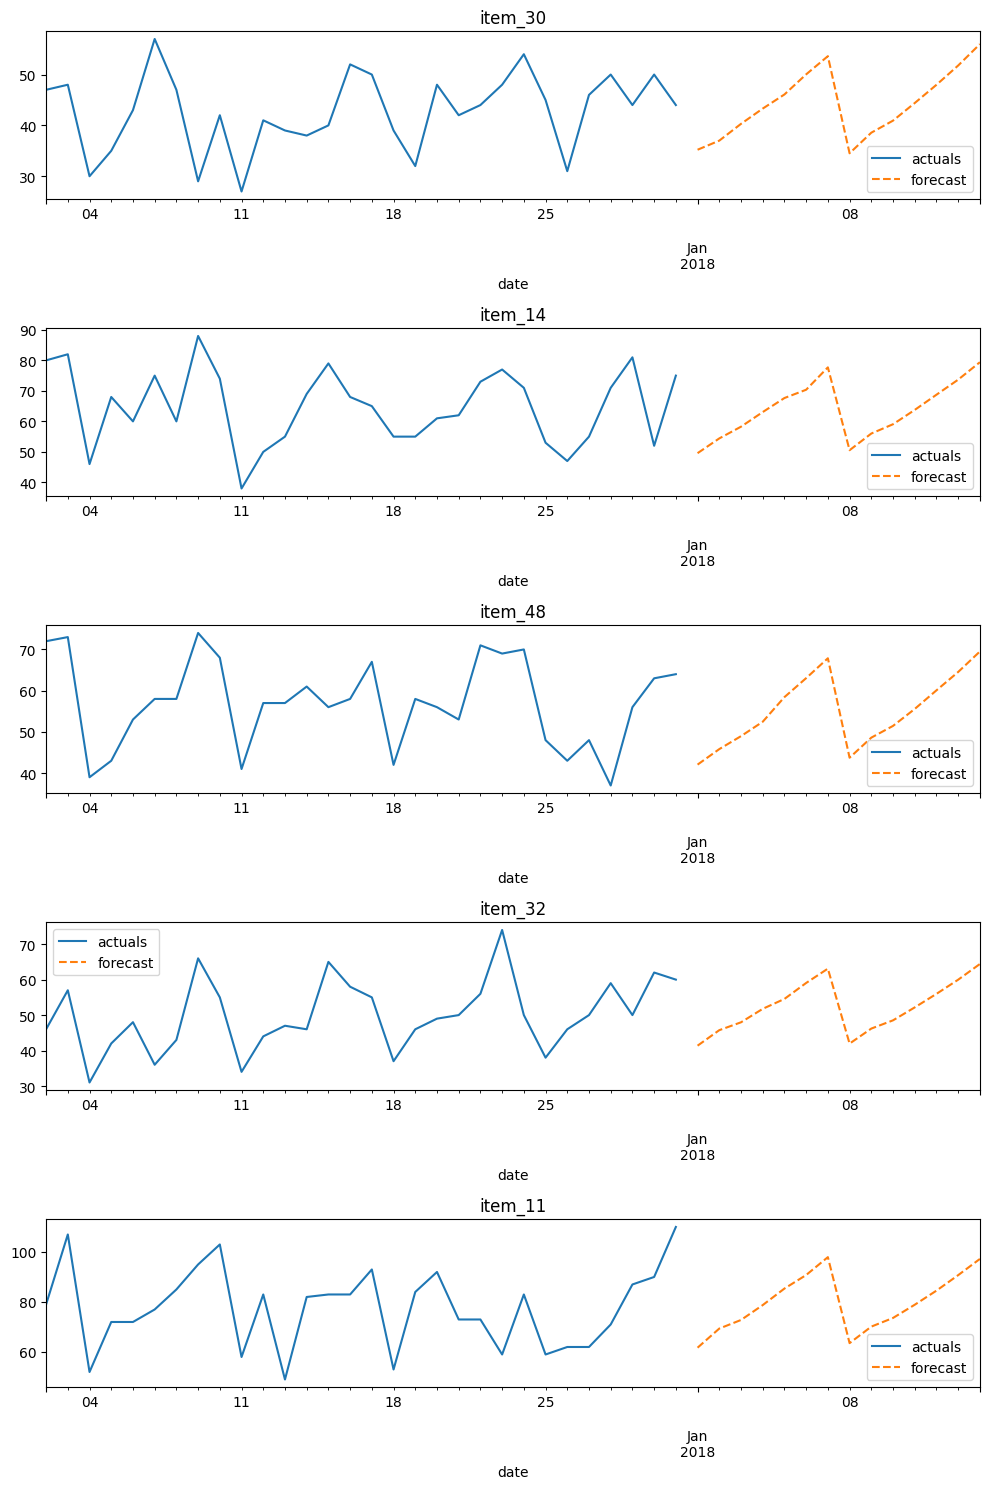

In [30]:
# Plot forecast

# Select a random subsample of timeseries
num_timeseries = 5
data_subset = data.sample(n=num_timeseries, axis=1, random_state=123)

# Plotting
fig, axs = plt.subplots(nrows=num_timeseries, figsize=[10, 3 * num_timeseries])
for ix in range(num_timeseries):
    item = data_subset.columns[ix]
    ax = axs[ix]

    data_subset.iloc[-30:][item].plot(ax=ax, label="actuals")
    forecast.loc[:, item].plot(ax=ax, linestyle="--", label="forecast")
    ax.legend()
    ax.set_title(f"{item}")

plt.tight_layout()

In [31]:
# Interval forecasts for item_1 and item_2
# See more details here: https://joaquinamatrodrigo.github.io/skforecast/0.11.0/user_guides/probabilistic-forecasting.html

forecast_intervals = forecaster.predict_interval(
    steps=steps, exog=future_exog, levels=["item_1", "item_2"]
)
forecast_intervals.head(3)

,item_1,item_1_lower_bound,item_1_upper_bound,item_2,item_2_lower_bound,item_2_upper_bound
2018-01-01,15.986802,7.147527,25.904777,53.492232,35.974758,70.789745
2018-01-02,18.700793,10.036954,28.141042,58.760329,43.566521,77.643189
2018-01-03,19.193270,9.447705,29.568743,61.598018,45.196923,78.320292


## Feature importance

In [32]:
# Feature importance
forecaster.get_feature_importances()

,feature,importance
9,roll_mean_30,0.280160
12,day_of_week,0.225057
1,lag_2,0.135270
2,lag_3,0.101595
6,lag_7,0.095984
7,roll_mean_7,0.087615
3,lag_4,0.080316
4,lag_5,0.078669
5,lag_6,0.061891
0,lag_1,0.059582


<Axes: xlabel='feature'>

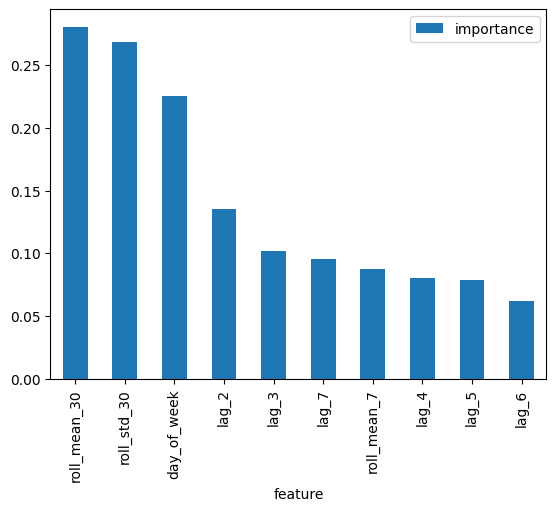

In [33]:
# Plot feature importance
(
    forecaster.get_feature_importances()
    .assign(importance=lambda df: np.abs(df.importance))
    .nlargest(n=10, columns=["importance"])
    .set_index("feature")
).plot(kind="bar")

## Weights in multi-series

The weights are used to control the influence that each observation has on the training of the model. `ForecasterAutoregMultiseries` accepts two types of weights:

+ `series_weights` controls the relative importance of each series. If a series has twice as much weight as the others, the observations of that series influence the training twice as much. The higher the weight of a series relative to the others, the more the model will focus on trying to learn that series.

+ `weight_func` controls the relative importance of each observation according to its index value. For example, a function that assigns a lower weight to certain dates.

If the two types of weights are indicated, they are **multiplied to create the final weights**. The resulting `sample_weight` cannot have negative values.

<p style="text-align: center">
<img src="./images/forecaster_multi_series_sample_weight.png" style="width: 900px">
<br>
<font size="2.5"> <i>Weights in multi-series.</i></font>
</p>

+ `series_weights` is a dict of the form `{'series_column_name': float}`. If a series is used during `fit` and is not present in `series_weights`, it will have a weight of 1.

+ `weight_func` is a function that defines the individual weights of each sample **based on the index**. 
  
    + If it is a `callable`, the same function will apply to all series. 
  
    + If it is a `dict` of the form `{'series_column_name': callable}`, a different function can be used for each series. A weight of 1 is given to all series not present in `weight_func`.

In [34]:
# Weights in Multi-Series


def custom_weights(index):
    """
    Return 0 if index is between '2013-01-01' and '2013-01-31', 1 otherwise.
    """
    weights = np.where((index >= "2013-01-01") & (index <= "2013-01-31"), 0, 1)

    return weights


forecaster = ForecasterRecursiveMultiSeries(
    regressor=Ridge(random_state=123),
    lags=24,
    transformer_series=StandardScaler(),
    transformer_exog=StandardScaler(),
    weight_func=custom_weights,
    series_weights={
        "item_1": 1.0,
        "item_2": 2.0,
        "item_3": 1.0,
    },  # Same as {'item_2': 2.}
)

forecaster.fit(series=data)
forecaster.predict(steps=24).head(3)

c:\Users\nuosv\Documents\PYTHON-PROJECTS\TRAINING_DATA_COURSES\forecasting-with-machine-learning\.venv\Lib\site-packages\skforecast\recursive\_forecaster_recursive_multiseries.py:1385: IgnoredArgumentWarning: {'item_23', 'item_21', 'item_28', 'day_of_week', 'item_29', 'item_32', 'item_39', 'item_12', 'item_44', 'item_33', 'item_41', 'item_43', 'item_15', 'item_20', 'item_8', 'item_45', 'item_47', 'item_24', 'item_17', 'item_34', 'item_5', 'item_6', 'item_38', 'item_11', 'item_19', 'item_10', 'item_18', 'item_26', 'item_40', 'item_16', 'item_27', 'item_13', 'item_14', 'item_50', 'item_35', 'item_30', 'item_37', 'item_9', 'item_22', 'item_36', 'item_42', 'item_48', 'item_4', 'item_7', 'item_31', 'item_46', 'item_49', 'item_25'} not present in `series_weights`. A weight of 1 is given to all their samples. 
 You can suppress this warning using: warnings.simplefilter('ignore', category=IgnoredArgumentWarning)
  warnings.warn(


,day_of_week,item_1,item_10,item_11,item_12,item_13,item_14,item_15,item_16,item_17,...,item_46,item_47,item_48,item_49,item_5,item_50,item_6,item_7,item_8,item_9
2018-01-01,0.877232,18.877371,68.006508,64.610476,62.948850,80.911148,52.151084,83.671214,20.494370,29.339274,...,57.033499,21.765658,45.209078,28.822969,18.526683,60.288162,51.935104,55.57906,74.166571,45.710497
2018-01-02,1.367788,19.921724,66.991418,77.810994,75.888589,90.349746,52.468320,93.257480,24.272062,34.530307,...,61.535581,23.198187,50.606595,31.696759,20.346375,59.167983,56.969335,62.71426,86.557796,45.647194
2018-01-03,2.095861,19.791656,72.417070,72.525339,76.678726,82.860815,58.641490,87.523764,24.393045,29.683608,...,63.974941,24.528487,51.807266,33.364037,17.385017,67.171600,60.884956,60.18592,90.815162,52.896800


<script src="https://kit.fontawesome.com/d20edc211b.js" crossorigin="anonymous"></script>

<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px;">
<p class="title">
    <i class="fa-triangle-exclamation fa" style="font-size: 18px; color:#ff9100;"></i>
    <b style="color: #ff9100;"> &nbsp Warning</b>
</p>

The <code>weight_func</code> and <code>series_weights</code> arguments will be ignored if the regressor does not accept <code>sample_weight</code> in its <code>fit</code> method.

</div>

The source code of the `weight_func` added to the forecaster is stored in the argument `source_code_weight_func`. If `weight_func` is a `dict`, it will be a `dict` of the form `{'series_column_name': source_code_weight_func}` .